# 1. Method walkthrough: A&B (1997) step by step

This notebook runs the core method on **one year of EUR/USD** so each step can be inspected. Nothing here is new relative to `src/intraday`; it only calls the library functions in order.

Prerequisite: `make data` (or `python scripts/01_download.py eurusd`).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from intraday.bars import get_panel
from intraday.garch import fit_ma1_garch11, conditional_sd, garch_by_frequency
from intraday.periodicity import fit_fff, mean_abs_profile
P = get_panel('eurusd')
R = P.R.loc['2024-10-01':'2025-09-30']
print(R.shape, 'days x intervals;', f'{(R == 0).to_numpy().mean():.1%} exact-zero returns')

(257, 288) days x intervals; 2.4% exact-zero returns


## Step 1 - the daily volatility factor $\sigma_t$
A daily MA(1)-GARCH(1,1). `conditional_sd` returns the one-step-ahead forecast, so $\sigma_t$ uses returns up to day $t-1$ only.

{'mu': 0.0013, 'theta': -0.0139, 'omega': 0.0013, 'alpha': 0.0373, 'beta': 0.9586}


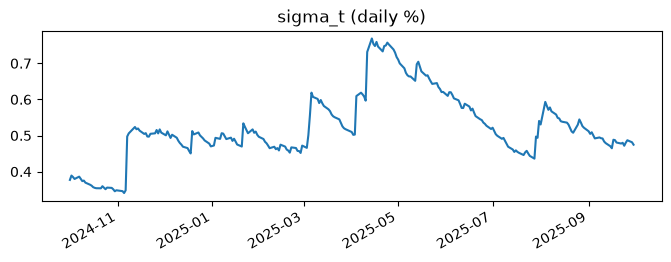

In [2]:
daily = P.daily.loc[:'2025-09-30']
dfit = fit_ma1_garch11(daily)
print(dfit.params.round(4).to_dict())
sigma = conditional_sd(dfit, daily).reindex(R.index)
sigma.plot(figsize=(8, 2.5), title='sigma_t (daily %)');

## Step 2 - the periodic component $s_n$
Model-free profile (average $|R_n|$ / average $|R|$) versus the Flexible Fourier Form estimated by Poisson PML. The FFF uses 2P+3 parameters instead of N=288.

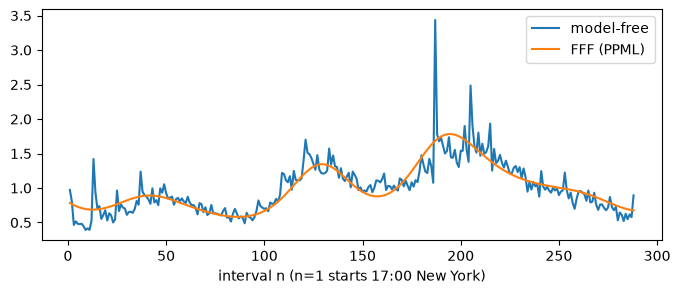

In [3]:
fff = fit_fff(R, sigma, P=6, J=0, method='ppml')
s_hat = fff.s_hat(sigma)
ax = mean_abs_profile(R).plot(figsize=(8, 3), label='model-free')
s_hat.mean().plot(ax=ax, label='FFF (PPML)'); ax.legend(); ax.set_xlabel('interval n (n=1 starts 17:00 New York)');

## Step 3 - GARCH at every sampling frequency, raw vs filtered
Aggregation theory says the half-life in *minutes* should not depend on k. Raw returns violate this badly; filtered returns much less.

In [4]:
raw = garch_by_frequency(R)
filt = garch_by_frequency(R / s_hat)
tab = pd.DataFrame({'raw a+b': raw.persistence, 'filtered a+b': filt.persistence,
                    'raw half-life (min)': raw.half_life, 'filtered half-life (min)': filt.half_life})
tab.round(3)

,raw a+b,filtered a+b,raw half-life (min),filtered half-life (min)
k,,,,
1,1.019,0.976,inf,142.546
2,1.005,0.976,inf,289.944
3,0.993,0.978,1577.119,469.081
4,0.992,0.971,1812.782,471.355
6,0.925,0.968,268.323,646.927
8,0.930,0.962,382.691,714.498
9,0.885,0.967,255.550,931.796
12,0.825,0.945,215.949,736.658
16,0.802,0.969,251.665,1749.331


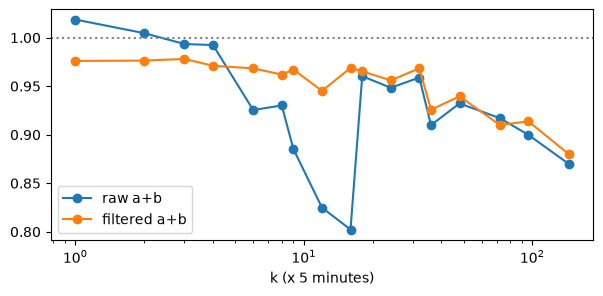

In [5]:
ax = tab[['raw a+b', 'filtered a+b']].clip(upper=1.05).plot(marker='o', logx=True, figsize=(7, 3))
ax.set_xlabel('k (x 5 minutes)'); ax.axhline(1, ls=':', c='grey');

**Reading the result.** Raw persistence is >1 at 5-10 minutes (nonstationary) and collapses at 1-1.5 hours; after dividing by $\hat s$ it is stable. This is A&B's Table 2 vs Table 4.